In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
from primordialpy.pbhabundance import PBHAbundance
from primordialpy.pbhconstraints import PBHConstraints
from primordialpy.inducedGW import InducedGW

import matplotlib.pyplot as plt

In [2]:
V = 'V0*(tanh(phi/sqrt(6)))**2*(1 + A*(sech((phi - phi0)/sigma))**2)'
parameters = {'V0' : 1.495e-10, 'A' : 1.080552e-3, 'phi0' : 5.301327, 'sigma': 1.940550e-2}
potential = PotentialFunction.function(V, param_values=parameters) 

#Creando instancia de la clase Background. Resuelve automáticamente el sistema dada la condición inicial del inflatón
background = Background(potential, phi0 = 6.3) 
background.solver()

In [3]:
#Extrayendo datos de la clase background
N, phi, dphidN, H, a, aH, eps_H, eta_H = background.data().values()
background.save_background(path='./Data')
Nend = N[-1]
Nend

Saved to ./Data/background.dat


np.float64(77.50775077507751)

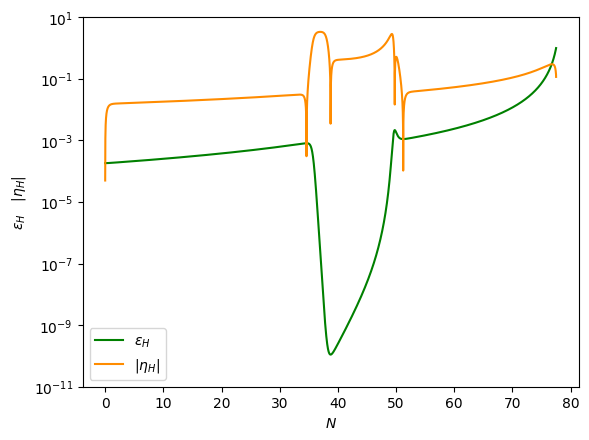

In [4]:
plt.plot(N, eps_H, label = r'$\epsilon_H$', color = 'green' )
plt.plot(N, abs(eta_H), label = r'$|\eta_H |$', color = 'darkorange')

plt.yscale('log')
plt.ylim(1e-11, 10)
plt.xlabel(r'$N$')
plt.ylabel(r'$\epsilon_H\quad |\eta_H|$')
plt.legend(loc = 3)
#plt.title('Slow-roll parameters')


In [9]:
pert = Perturbations(potential, background, scale= 'PBH', N_CMB = 63)
sol_pivot = pert.power_spectra_pivot()

Curvature power spectrum at pivot scale is 2.116659739577822e-09
Tensor to scalar ratio at pivot scale is 0.00462943633368454


In [10]:
PS = pert.power_spectrum()
pert.save_power_spectra(path ='./Data')

Computing P(k): 100%|██████████| 1000/1000 [00:29<00:00, 33.77it/s]


$Ps_peak = 3.5208\times 10^{-02}$
$k_peak = 3.6556\times 10^{+08}\,\mathrm{Mpc}^-1$
Saved to ./Data/power_spectra.dat


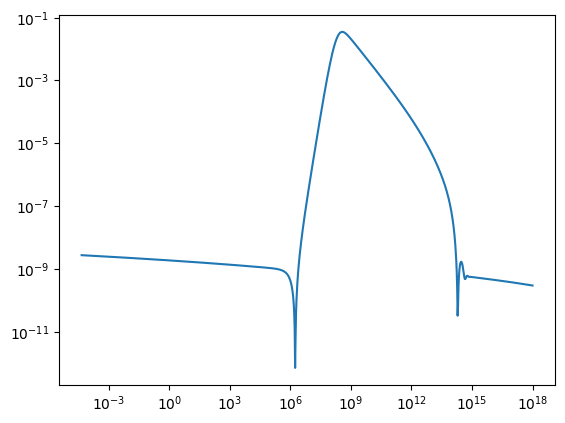

In [11]:
plt.loglog(pert.k_modes, PS[0])

In [12]:
pert.spectral_tilts

{'n_s': 0.9603630731586553, 'n_t': -0.000602458548414453}

In [13]:
pbh = PBHAbundance(perturbations=pert, delta_c=0.4, gamma=0.2, gstar=107.5)
mPBH, fPBH = pbh.fPBH()
pbh.save_pbh(path='./Data')

fPBH_peak = 0.015374488989034787
MPBH_peak = 2.305236922616886e-05 M⊙
Saved to ./Data/pbh_abundance.dat


In [ ]:
constraints = PBHConstraints()
constraints.add_bound('Evap', 'Evaporation.txt')
constraints.add_bound('HSC',  'HSC.txt')
constraints.add_bound('CMB', 'CMB.txt')
constraints.add_bound('LIGO', 'LIGO.txt')
constraints.add_bound('Accretion', 'Accretion.txt')
constraints.add_bound('Dynamical', 'Dynamical.txt')
constraints.add_bound('EROS', 'EROS.txt')
constraints.add_bound('Kepler', 'Kepler.txt')
constraints.add_bound('Microlensing', 'Microlensing.txt')

constraints.plot_constraints(m_pbh=mPBH, f_pbh=fPBH)

In [ ]:
gw = InducedGW(perturbations=pert)
f, omega = gw.compute(n_int= 500)
gw.save_gw(path= './Data')

In [ ]:
plt.loglog(f, omega)
plt.ylim(1e-18, 1e-6)
plt.xlim(1e-13)
